# Fintech Credit Risk Analysis & Loan Default Prediction

## Business Problem

A fintech lending company wants to improve its credit risk management by identifying borrowers who may present a higher risk of loan default.

Loan defaults can result in financial losses, while overly restrictive lending decisions may cause the company to reject potentially profitable customers. The business therefore needs a data-driven approach that balances risk management with lending opportunities.

## Project Objective

This project uses historical loan and borrower data to:

- Analyse borrower and loan characteristics associated with credit risk.
- Identify patterns and factors that may contribute to poor loan performance.
- Develop a machine learning model to estimate borrower default risk.
- Segment borrowers according to predicted risk.
- Translate analytical findings into actionable recommendations for lending and risk-management decisions.

## Business Question

**Which borrower and loan characteristics are associated with higher credit risk, and can historical lending data be used to predict borrowers who are more likely to default?**


In [1]:
# Import libraries for data analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")


In [2]:
# Load the raw Lending Club dataset

df = pd.read_csv("../data/raw/loans_full_schema.csv")

## 1. Data Understanding

Before cleaning or modelling the data, the dataset is examined to understand its structure, variables, data types, completeness, and potential data-quality issues.

In [3]:
# Display the first five records
display(df.head())

# Dataset dimensions
print("Number of loans:", df.shape[0])
print("Number of variables:", df.shape[1])

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types and non-null counts
print("\nDataset Information:")
df.info()

# Missing values
missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_percentage = (
    df.isnull()
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage
})

print("\nVariables with Missing Data:")
display(missing_summary[missing_summary["Missing Values"] > 0])

# Duplicate records
print("\nDuplicate Rows:", df.duplicated().sum())

# Numerical summary
print("\nNumerical Variable Summary:")
display(df.describe().T)

,Unnamed: 0,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,1,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,2,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,3,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,4,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,5,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


Number of loans: 10000
Number of variables: 56

Column Names:
['Unnamed: 0', 'emp_title', 'emp_length', 'state', 'homeownership', 'annual_income', 'verified_income', 'debt_to_income', 'annual_income_joint', 'verification_income_joint', 'debt_to_income_joint', 'delinq_2y', 'months_since_last_delinq', 'earliest_credit_line', 'inquiries_last_12m', 'total_credit_lines', 'open_credit_lines', 'total_credit_limit', 'total_credit_utilized', 'num_collections_last_12m', 'num_historical_failed_to_pay', 'months_since_90d_late', 'current_accounts_delinq', 'total_collection_amount_ever', 'current_installment_accounts', 'accounts_opened_24m', 'months_since_last_credit_inquiry', 'num_satisfactory_accounts', 'num_accounts_120d_past_due', 'num_accounts_30d_past_due', 'num_active_debit_accounts', 'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts', 'num_cc_carrying_balance', 'num_mort_accounts', 'account_never_delinq_percent', 'tax_liens', 'public_record_bankrupt', 'loan_purpose', 'appli

,Missing Values,Missing Percentage (%)
verification_income_joint,8545,85.45
annual_income_joint,8505,85.05
debt_to_income_joint,8505,85.05
months_since_90d_late,7715,77.15
months_since_last_delinq,5658,56.58
months_since_last_credit_inquiry,1271,12.71
emp_title,833,8.33
emp_length,817,8.17
num_accounts_120d_past_due,318,3.18
debt_to_income,24,0.24



Duplicate Rows: 0

Numerical Variable Summary:


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,10000.0,5000.500000,2886.895680,1.00,2500.7500,5000.500,7500.2500,1.000000e+04
emp_length,9183.0,5.930306,3.703734,0.00,2.0000,6.000,10.0000,1.000000e+01
annual_income,10000.0,79222.148412,64734.290492,0.00,45000.0000,65000.000,95000.0000,2.300000e+06
debt_to_income,9976.0,19.308192,15.004851,0.00,11.0575,17.570,25.0025,4.690900e+02
annual_income_joint,1495.0,127914.571244,70168.375404,19200.00,86833.5000,113000.000,151545.5000,1.100000e+06
debt_to_income_joint,1495.0,19.979304,8.054781,0.32,14.1600,19.720,25.5000,3.998000e+01
delinq_2y,10000.0,0.216000,0.683660,0.00,0.0000,0.000,0.0000,1.300000e+01
months_since_last_delinq,4342.0,36.760709,21.634939,1.00,19.0000,34.000,53.0000,1.180000e+02
earliest_credit_line,10000.0,2001.290000,7.795510,1963.00,1997.0000,2003.000,2006.0000,2.015000e+03
inquiries_last_12m,10000.0,1.958200,2.380130,0.00,0.0000,1.000,3.0000,2.900000e+01


## 2. Data Cleaning and Preparation

The dataset contains missing values across several borrower and credit-related variables. Before conducting exploratory analysis and predictive modelling, the data is cleaned to improve consistency and analytical reliability.

Variables with extremely high levels of missing information are removed where they provide limited analytical value. Remaining missing values are handled according to the characteristics and meaning of each variable.

In [4]:
# Create a copy of the original dataset
df_clean = df.copy()

# --------------------------------------------------
# 1. Remove columns with more than 50% missing values
# --------------------------------------------------

missing_pct = df_clean.isnull().mean() * 100

high_missing_cols = missing_pct[missing_pct > 50].index.tolist()

print("Columns removed due to >50% missing data:")
print(high_missing_cols)

df_clean = df_clean.drop(columns=high_missing_cols)


# --------------------------------------------------
# 2. Handle remaining missing numerical values
# --------------------------------------------------

numeric_cols = df_clean.select_dtypes(include=np.number).columns

for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())


# --------------------------------------------------
# 3. Handle remaining categorical missing values
# --------------------------------------------------

categorical_cols = df_clean.select_dtypes(include="object").columns

for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna("Unknown")


# --------------------------------------------------
# 4. Check the cleaned dataset
# --------------------------------------------------

print("\nOriginal dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

print("\nRemaining missing values:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

Columns removed due to >50% missing data:
['annual_income_joint', 'verification_income_joint', 'debt_to_income_joint', 'months_since_last_delinq', 'months_since_90d_late']

Original dataset shape: (10000, 56)
Cleaned dataset shape: (10000, 51)

Remaining missing values:
0

Duplicate rows:
0


## 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is conducted to understand the financial and credit characteristics of borrowers and identify patterns that may influence lending risk.

The analysis focuses on loan size, interest rates, borrower income, debt-to-income ratios, loan grades, loan purposes, and other characteristics relevant to credit-risk decision-making.

In [5]:
# Key lending portfolio metrics

print("LOAN PORTFOLIO OVERVIEW")
print("-" * 40)

print(f"Total Loans: {len(df_clean):,}")
print(f"Total Loan Value: ${df_clean['loan_amount'].sum():,.2f}")
print(f"Average Loan Amount: ${df_clean['loan_amount'].mean():,.2f}")
print(f"Median Loan Amount: ${df_clean['loan_amount'].median():,.2f}")
print(f"Average Interest Rate: {df_clean['interest_rate'].mean():.2f}%")
print(f"Average Annual Income: ${df_clean['annual_income'].mean():,.2f}")
print(f"Average Debt-to-Income Ratio: {df_clean['debt_to_income'].mean():.2f}")

LOAN PORTFOLIO OVERVIEW
----------------------------------------
Total Loans: 10,000
Total Loan Value: $163,619,225.00
Average Loan Amount: $16,361.92
Median Loan Amount: $14,500.00
Average Interest Rate: 12.43%
Average Annual Income: $79,222.15
Average Debt-to-Income Ratio: 19.30


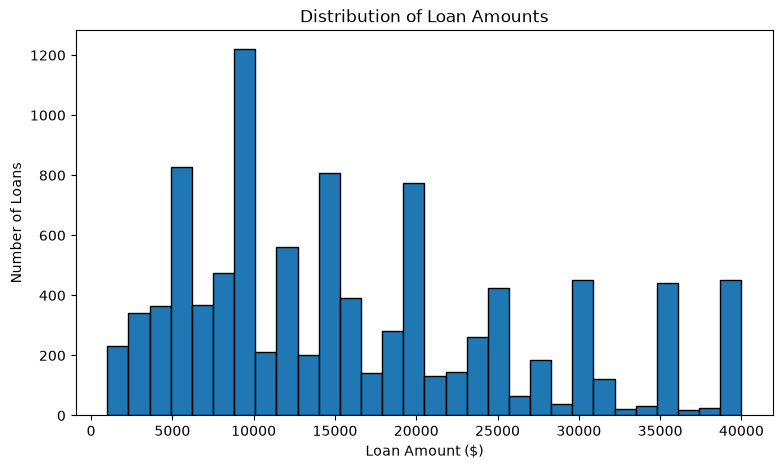

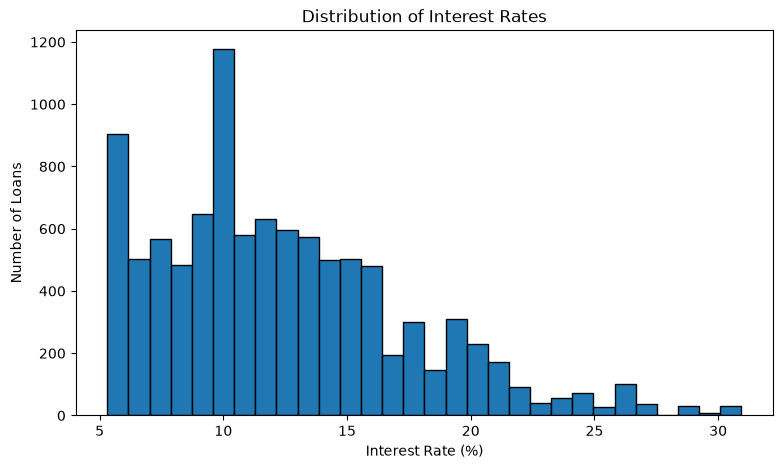

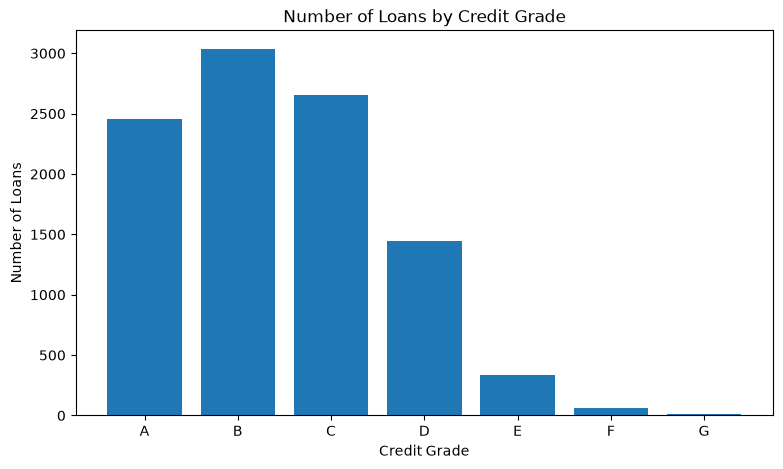

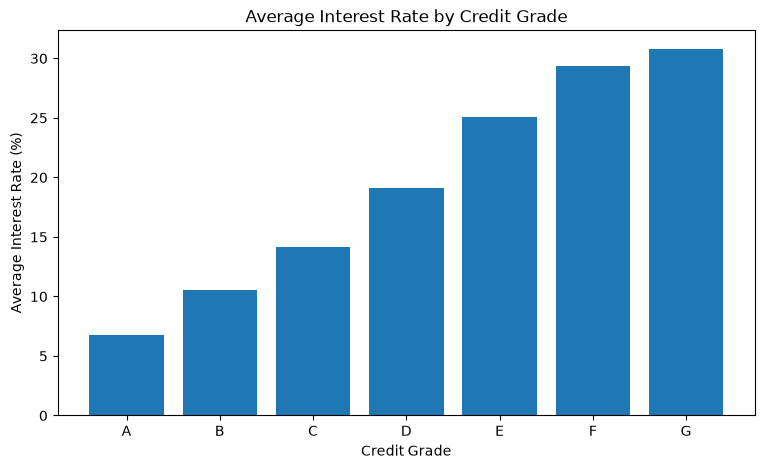

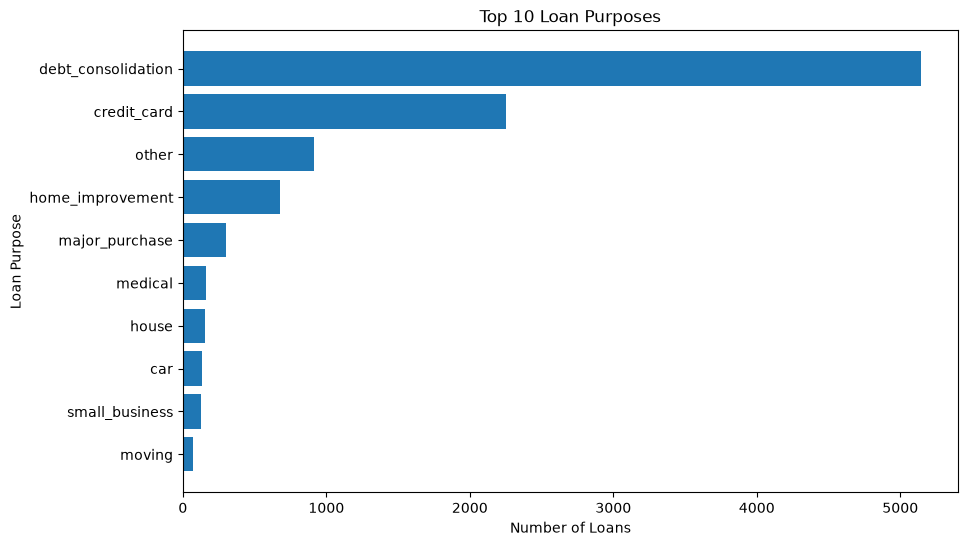

In [6]:
# Distribution of loan amounts

plt.figure(figsize=(9, 5))
plt.hist(df_clean["loan_amount"], bins=30, edgecolor="black")
plt.title("Distribution of Loan Amounts")
plt.xlabel("Loan Amount ($)")
plt.ylabel("Number of Loans")
plt.show()


# Distribution of interest rates

plt.figure(figsize=(9, 5))
plt.hist(df_clean["interest_rate"], bins=30, edgecolor="black")
plt.title("Distribution of Interest Rates")
plt.xlabel("Interest Rate (%)")
plt.ylabel("Number of Loans")
plt.show()


# Loan grade distribution

plt.figure(figsize=(9, 5))

grade_counts = df_clean["grade"].value_counts().sort_index()

plt.bar(grade_counts.index, grade_counts.values)
plt.title("Number of Loans by Credit Grade")
plt.xlabel("Credit Grade")
plt.ylabel("Number of Loans")
plt.show()


# Average interest rate by credit grade

grade_interest = (
    df_clean.groupby("grade")["interest_rate"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(9, 5))
plt.bar(grade_interest.index, grade_interest.values)
plt.title("Average Interest Rate by Credit Grade")
plt.xlabel("Credit Grade")
plt.ylabel("Average Interest Rate (%)")
plt.show()


# Most common loan purposes

purpose_counts = df_clean["loan_purpose"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(purpose_counts.index, purpose_counts.values)
plt.title("Top 10 Loan Purposes")
plt.xlabel("Number of Loans")
plt.ylabel("Loan Purpose")
plt.gca().invert_yaxis()
plt.show()

## 4. Credit Risk Target Definition

To develop a predictive credit-risk model, the loan outcome variable is examined to determine how loan performance should be classified.

The objective is to create a binary target that distinguishes higher-risk/default outcomes from successfully performing loans.

In [7]:
# Examine the loan status variable

print("Loan Status Categories:")
print(df_clean["loan_status"].value_counts())

print("\nLoan Status Percentages:")
print(
    df_clean["loan_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Loan Status Categories:
loan_status
Current               9375
Fully Paid             447
In Grace Period         67
Late (31-120 days)      66
Late (16-30 days)       38
Charged Off              7
Name: count, dtype: int64

Loan Status Percentages:
loan_status
Current               93.75
Fully Paid             4.47
In Grace Period        0.67
Late (31-120 days)     0.66
Late (16-30 days)      0.38
Charged Off            0.07
Name: proportion, dtype: float64


## 5. Credit Risk Target Definition

The original project objective was to predict loan default. However, examination of the loan status variable revealed that only a very small number of loans were classified as "Charged Off."

Using only charged-off loans as the target would produce an extremely imbalanced dataset and would not provide enough default cases to develop a reliable predictive model.

Therefore, the analysis defines an **Adverse Loan Status** as a loan that is currently experiencing repayment difficulty. This includes:

- In Grace Period
- Late (16–30 days)
- Late (31–120 days)
- Charged Off

Loans classified as **Current** or **Fully Paid** are treated as performing loans.

The predictive objective is therefore to identify borrowers who are more likely to experience repayment difficulty or adverse loan performance.

In [8]:
# Define adverse loan statuses

adverse_statuses = [
    "In Grace Period",
    "Late (16-30 days)",
    "Late (31-120 days)",
    "Charged Off"
]

# Create binary credit-risk target
df_clean["credit_risk"] = (
    df_clean["loan_status"]
    .isin(adverse_statuses)
    .astype(int)
)

# Examine target distribution
risk_counts = df_clean["credit_risk"].value_counts()
risk_percent = (
    df_clean["credit_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Credit Risk Distribution")
print("-" * 35)

print(f"Performing Loans (0): {risk_counts.get(0, 0):,}")
print(f"Adverse Loans (1): {risk_counts.get(1, 0):,}")

print("\nPercentage Distribution:")
print(risk_percent)

Credit Risk Distribution
-----------------------------------
Performing Loans (0): 9,822
Adverse Loans (1): 178

Percentage Distribution:
credit_risk
0    98.22
1     1.78
Name: proportion, dtype: float64


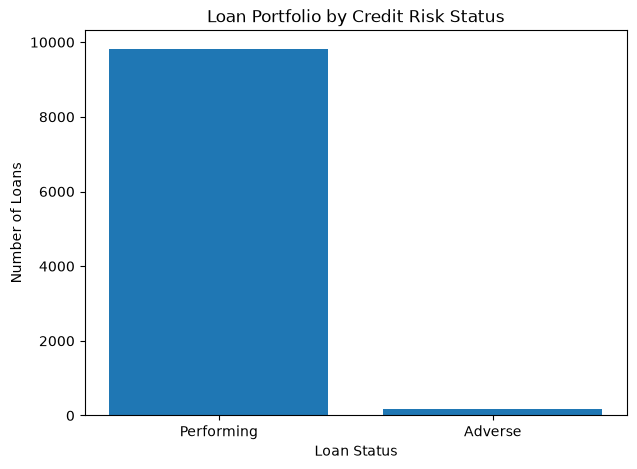

In [9]:
# Visualize performing vs adverse loans

risk_labels = (
    df_clean["credit_risk"]
    .map({0: "Performing", 1: "Adverse"})
    .value_counts()
)

plt.figure(figsize=(7, 5))
plt.bar(risk_labels.index, risk_labels.values)

plt.title("Loan Portfolio by Credit Risk Status")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")

plt.show()

## 6. Feature Selection and Data Leakage Prevention

For a credit-risk model to be useful in lending decisions, predictor variables should represent information that would reasonably be available when the borrower applies for the loan.

Variables describing repayment behaviour after loan issuance are excluded because they would introduce **data leakage** and artificially inflate model performance.

Examples of excluded post-loan variables include outstanding balance, principal paid, interest paid, late fees paid, and loan status.

In [10]:
# Columns that would create data leakage

leakage_columns = [
    "loan_status",
    "balance",
    "paid_total",
    "paid_principal",
    "paid_interest",
    "paid_late_fees"
]

# Keep target separately
y = df_clean["credit_risk"]

# Remove target and leakage variables
X = df_clean.drop(
    columns=leakage_columns + ["credit_risk"],
    errors="ignore"
)

print("Predictor dataset shape:", X.shape)
print("Target shape:", y.shape)

Predictor dataset shape: (10000, 45)
Target shape: (10000,)


In [11]:
underwriting_output_columns = [
    "grade",
    "sub_grade",
    "interest_rate"
]

X = X.drop(
    columns=underwriting_output_columns,
    errors="ignore"
)

print("Final predictor dataset shape:", X.shape)

Final predictor dataset shape: (10000, 42)


## 7. Model Development

A Logistic Regression model is developed as the baseline credit-risk classifier.

Because adverse loan outcomes represent a relatively small proportion of the portfolio, the modelling approach accounts for class imbalance. The data is divided into training and testing sets using stratification to preserve the proportion of performing and adverse loans.

Numerical variables are standardized, while categorical variables are converted into machine-readable indicators using one-hot encoding.

Model performance is evaluated using precision, recall, F1-score, confusion matrix, and ROC-AUC rather than accuracy alone.

In [12]:
# Import machine learning tools

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Identify numerical and categorical variables
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 33
Categorical features: 9


In [13]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training observations: 8000
Testing observations: 2000

Training target distribution:
credit_risk
0    7858
1     142
Name: count, dtype: int64

Testing target distribution:
credit_risk
0    1964
1      36
Name: count, dtype: int64


In [14]:
# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

print("Model pipeline created successfully.")

Model pipeline created successfully.


In [15]:
# Train Logistic Regression model

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [16]:
# Generate predictions

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# Classification report
print("LOGISTIC REGRESSION PERFORMANCE")
print("-" * 45)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Performing", "Adverse"]
))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.3f}")

LOGISTIC REGRESSION PERFORMANCE
---------------------------------------------
              precision    recall  f1-score   support

  Performing       0.98      0.91      0.95      1964
     Adverse       0.03      0.17      0.06        36

    accuracy                           0.90      2000
   macro avg       0.51      0.54      0.50      2000
weighted avg       0.97      0.90      0.93      2000

ROC-AUC Score: 0.579


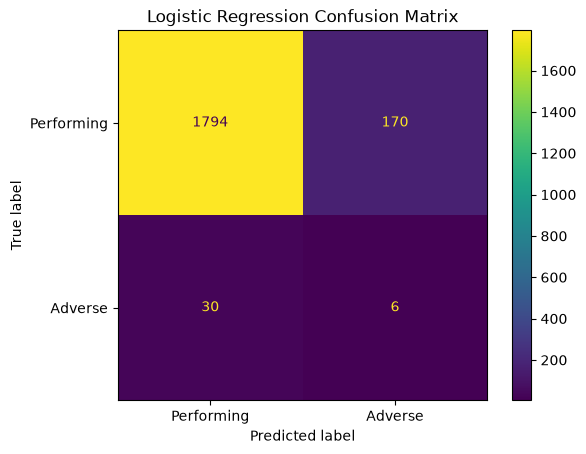

In [17]:
# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Performing", "Adverse"],
    values_format="d"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

## 8. Random Forest Model

A Random Forest classifier is developed as an alternative to Logistic Regression.

Random Forest can capture more complex and non-linear relationships between borrower characteristics and credit risk. Class weighting is applied to account for the imbalance between performing and adverse loans.

The performance of both models will subsequently be compared to determine which provides the most useful credit-risk predictions.

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [19]:
# Generate Random Forest predictions

rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("RANDOM FOREST PERFORMANCE")
print("-" * 45)

print(classification_report(
    y_test,
    rf_pred,
    target_names=["Performing", "Adverse"]
))

rf_roc_auc = roc_auc_score(y_test, rf_prob)

print(f"ROC-AUC Score: {rf_roc_auc:.3f}")

RANDOM FOREST PERFORMANCE
---------------------------------------------
              precision    recall  f1-score   support

  Performing       0.98      1.00      0.99      1964
     Adverse       0.00      0.00      0.00        36

    accuracy                           0.98      2000
   macro avg       0.49      0.50      0.50      2000
weighted avg       0.96      0.98      0.97      2000

ROC-AUC Score: 0.598


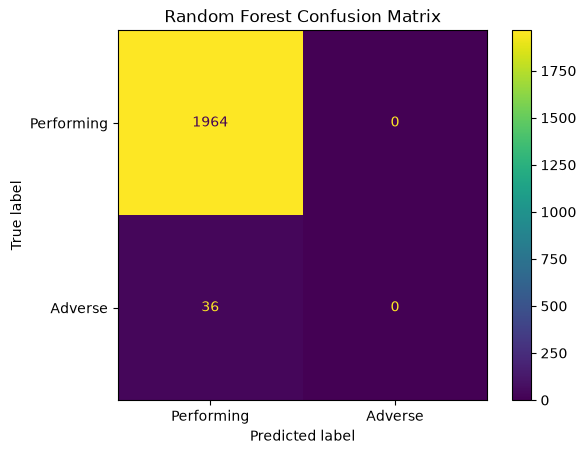

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["Performing", "Adverse"],
    values_format="d"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

## 9. Model Comparison

The Logistic Regression and Random Forest models are compared using metrics appropriate for an imbalanced credit-risk problem.

Particular attention is given to the ability of each model to identify adverse loans while limiting the number of performing borrowers incorrectly classified as high risk.

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision (Adverse)": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred, zero_division=0)
    ],
    "Recall (Adverse)": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred, zero_division=0)
    ],
    "F1 Score (Adverse)": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc
    ]
})

display(
    model_comparison.style.format({
        "Precision (Adverse)": "{:.3f}",
        "Recall (Adverse)": "{:.3f}",
        "F1 Score (Adverse)": "{:.3f}",
        "ROC-AUC": "{:.3f}"
    })
)

,Model,Precision (Adverse),Recall (Adverse),F1 Score (Adverse),ROC-AUC
0,Logistic Regression,0.034,0.167,0.057,0.579
1,Random Forest,0.000,0.000,0.000,0.598


## 10. Credit Risk Drivers

Predictive performance alone does not explain why borrowers are classified as higher risk.

To support business decision-making, the Logistic Regression model is examined to identify the borrower and loan characteristics most strongly associated with adverse loan outcomes.

Positive coefficients indicate characteristics associated with higher predicted credit risk, while negative coefficients indicate characteristics associated with lower predicted risk.

In [22]:
# Extract feature names after preprocessing

feature_names = logistic_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Extract Logistic Regression coefficients

coefficients = logistic_model.named_steps[
    "classifier"
].coef_[0]

feature_effects = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Largest positive coefficients = higher predicted risk
higher_risk_drivers = (
    feature_effects
    .sort_values("Coefficient", ascending=False)
    .head(10)
)

# Largest negative coefficients = lower predicted risk
lower_risk_drivers = (
    feature_effects
    .sort_values("Coefficient", ascending=True)
    .head(10)
)

print("TOP CHARACTERISTICS ASSOCIATED WITH HIGHER PREDICTED RISK")
display(higher_risk_drivers)

print("\nTOP CHARACTERISTICS ASSOCIATED WITH LOWER PREDICTED RISK")
display(lower_risk_drivers)

TOP CHARACTERISTICS ASSOCIATED WITH HIGHER PREDICTED RISK


,Feature,Coefficient
709,cat__emp_title_command master chief,5.650366
3300,cat__emp_title_service advisor,5.179781
2557,cat__emp_title_pipewelder,5.025127
2412,cat__emp_title_owner/operater,4.998107
3532,cat__emp_title_staff coordinator,4.988224
3597,cat__emp_title_supervisor front desk,4.863325
1838,cat__emp_title_lawn care owner,4.821457
523,cat__emp_title_carpenter foreman,4.780337
3094,cat__emp_title_salesman,4.757341
2752,cat__emp_title_project manager,4.537538



TOP CHARACTERISTICS ASSOCIATED WITH LOWER PREDICTED RISK


,Feature,Coefficient
4052,cat__loan_purpose_small_business,-2.267127
30,num__loan_amount,-2.176083
14,num__total_collection_amount_ever,-1.960687
4025,cat__state_SC,-1.798999
4001,cat__state_KS,-1.454785
2997,cat__emp_title_rn,-1.337517
1028,cat__emp_title_director,-1.278036
4014,cat__state_NE,-1.220089
4015,cat__state_NH,-1.150211
4024,cat__state_RI,-1.142493


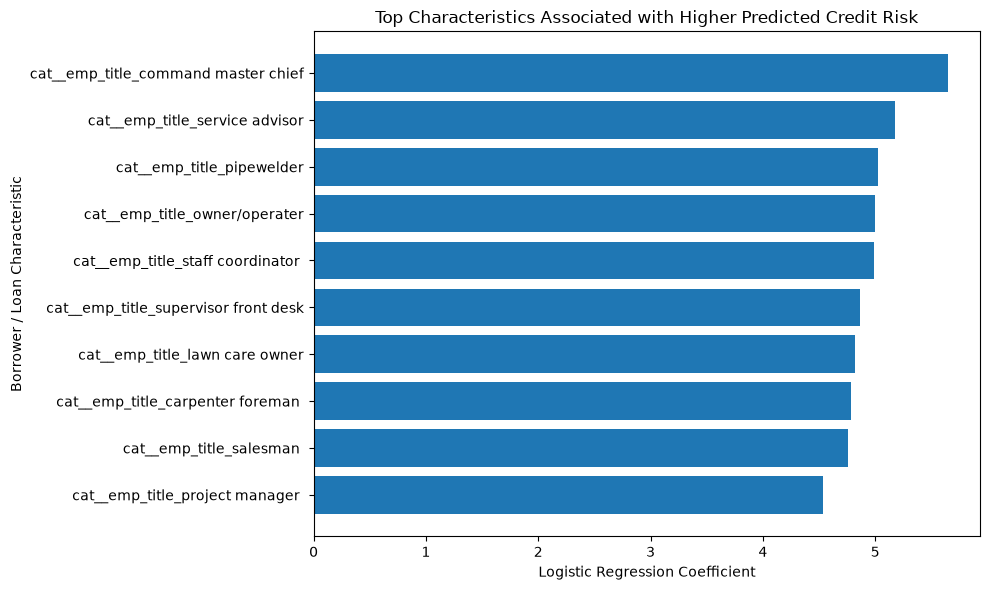

In [23]:
# Plot characteristics associated with higher predicted risk

plot_data = higher_risk_drivers.sort_values("Coefficient")

plt.figure(figsize=(10, 6))
plt.barh(plot_data["Feature"], plot_data["Coefficient"])

plt.title("Top Characteristics Associated with Higher Predicted Credit Risk")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Borrower / Loan Characteristic")

plt.tight_layout()
plt.show()

## 11. Borrower Risk Scoring

Predicted probabilities from the selected credit-risk model can be used as risk scores rather than relying solely on binary classifications.

This allows borrowers to be ranked according to their estimated probability of experiencing an adverse loan outcome and provides a foundation for risk-based decision support.

In [24]:
# Create risk scores for the test population

risk_results = X_test.copy()

risk_results["Actual_Risk"] = y_test.values
risk_results["Predicted_Risk_Probability"] = y_prob

# Convert probability to percentage
risk_results["Risk_Score_Percent"] = (
    risk_results["Predicted_Risk_Probability"] * 100
).round(2)

display(
    risk_results[
        ["Actual_Risk",
         "Predicted_Risk_Probability",
         "Risk_Score_Percent"]
    ].head(10)
)

,Actual_Risk,Predicted_Risk_Probability,Risk_Score_Percent
644,0,0.036741,3.67
1208,0,0.196994,19.70
8128,0,0.059562,5.96
2086,0,0.339709,33.97
7761,0,0.412604,41.26
9086,0,0.583542,58.35
1238,0,0.039248,3.92
1786,0,0.009224,0.92
3479,0,0.030014,3.00
265,0,0.115231,11.52


In [25]:
# Segment borrowers according to predicted risk

risk_results["Risk_Segment"] = pd.qcut(
    risk_results["Predicted_Risk_Probability"],
    q=4,
    labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Very High Risk"
    ]
)

risk_segment_summary = (
    risk_results
    .groupby("Risk_Segment", observed=False)
    .agg(
        Borrowers=("Actual_Risk", "size"),
        Actual_Adverse_Loans=("Actual_Risk", "sum"),
        Average_Predicted_Risk=("Predicted_Risk_Probability", "mean")
    )
    .reset_index()
)

risk_segment_summary["Actual_Adverse_Rate"] = (
    risk_segment_summary["Actual_Adverse_Loans"]
    / risk_segment_summary["Borrowers"]
)

risk_segment_summary["Average_Predicted_Risk"] *= 100
risk_segment_summary["Actual_Adverse_Rate"] *= 100

display(
    risk_segment_summary.style.format({
        "Average_Predicted_Risk": "{:.2f}%",
        "Actual_Adverse_Rate": "{:.2f}%"
    })
)

,Risk_Segment,Borrowers,Actual_Adverse_Loans,Average_Predicted_Risk,Actual_Adverse_Rate
0,Low Risk,500,6,1.70%,1.20%
1,Moderate Risk,500,8,6.16%,1.60%
2,High Risk,500,10,15.40%,2.00%
3,Very High Risk,500,12,46.63%,2.40%


## 12. Business Interpretation

The risk segmentation demonstrates that the model can rank borrowers according to relative credit risk.

Observed adverse loan rates increased progressively across the four risk segments:

- Low Risk: 1.20%
- Moderate Risk: 1.60%
- High Risk: 2.00%
- Very High Risk: 2.40%

The Very High Risk segment experienced an adverse rate twice that of the Low Risk segment. This suggests that the model provides useful discriminatory information for identifying borrowers who may warrant additional attention.

However, predicted probabilities were considerably higher than the observed adverse rates, particularly among higher-risk borrowers. Therefore, the model should currently be interpreted primarily as a **risk-ranking tool rather than a fully calibrated probability-of-default model**.

From a business perspective, these risk rankings could support differentiated underwriting, manual review, and portfolio monitoring rather than being used as an automatic approval or rejection mechanism.

## 13. Business Recommendations

Based on the analysis, the fintech lender could consider the following actions:

1. **Introduce risk-based application review**  
   Use model-generated risk rankings to identify applicants who may require additional underwriting or documentation.

2. **Prioritize higher-risk borrowers for review**  
   Borrowers classified in the High and Very High Risk segments could receive enhanced affordability and credit-history assessment before a lending decision is made.

3. **Maintain streamlined processing for lower-risk applicants**  
   Lower-risk borrowers may be suitable for more streamlined review processes, subject to the lender's existing underwriting requirements.

4. **Use risk scores for portfolio monitoring**  
   Risk segmentation can help management prioritize accounts for monitoring and early intervention.

5. **Improve probability calibration before production use**  
   Because predicted probabilities exceed observed adverse rates, further model calibration and validation should be completed before interpreting the scores as actual probabilities of adverse outcomes.

6. **Combine predictive analytics with existing underwriting controls**  
   The model should support, rather than replace, established credit policies and human decision-making.

## 14. Model Limitations

Several limitations should be considered when interpreting the results:

- Adverse loan outcomes represent a small proportion of the dataset, creating a significant class-imbalance problem.
- The target combines charged-off, late, and grace-period loans into a broader adverse-loan category because the dataset contains very few charged-off loans.
- Many loans are currently active, meaning their ultimate repayment outcomes are not yet known.
- Class weighting improves the model's ability to identify minority-class observations but can affect probability calibration.
- The analysis is based on historical observational data and does not establish causal relationships between borrower characteristics and loan outcomes.
- The model has not undergone external, temporal, fairness, or production-level validation.
- Credit-risk models used in real lending environments require additional governance, regulatory review, monitoring, and validation.

Therefore, the model should be viewed as an analytical decision-support prototype rather than a production lending system.

## 15. Conclusion

This project demonstrates how Python and machine learning can be applied to a fintech credit-risk problem while maintaining a strong focus on business decision-making.

The analysis progressed from data-quality assessment and exploratory analysis through feature engineering, leakage prevention, predictive modelling, model comparison, risk-driver analysis, and borrower segmentation.

The resulting model demonstrated an ability to rank borrowers by relative risk, with observed adverse rates increasing from 1.20% among Low Risk borrowers to 2.40% among Very High Risk borrowers.

Rather than using the model as an automated lending decision engine, the results support its potential use as a decision-support tool for borrower prioritization, enhanced underwriting, and portfolio monitoring.

Further development should focus on probability calibration, additional historical loan outcomes, model validation, fairness assessment, and performance monitoring before any production deployment.

In [26]:
# Save borrower risk segmentation results

risk_output = risk_results[
    [
        "Actual_Risk",
        "Predicted_Risk_Probability",
        "Risk_Score_Percent",
        "Risk_Segment"
    ]
].copy()

risk_output.to_csv(
    "../data/processed/borrower_risk_scores.csv",
    index=False
)

print("Borrower risk scores saved successfully.")

Borrower risk scores saved successfully.


In [27]:
# Save model comparison results

model_comparison.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [28]:
# Save risk segment summary

risk_segment_summary.to_csv(
    "../data/processed/risk_segment_summary.csv",
    index=False
)

print("Risk segment summary saved successfully.")

Risk segment summary saved successfully.


## Model Performance

The two models produced the following results:

| Model | Adverse Precision | Adverse Recall | Adverse F1-Score | ROC-AUC |
|---|---:|---:|---:|---:|
| Logistic Regression | 0.034 | 0.167 | 0.057 | 0.579 |
| Random Forest | 0.000 | 0.000 | 0.000 | 0.598 |

The results demonstrate the difficulty of predicting adverse loan outcomes within this dataset.

Random Forest achieved the higher ROC-AUC score (0.598), indicating slightly better overall ranking ability. However, at the default classification threshold, it failed to identify any adverse loans.

Logistic Regression achieved an adverse-loan recall of 16.7%, meaning it identified some adverse cases, but its low precision indicates a high number of false-positive classifications.

Neither model currently demonstrates sufficient predictive performance for use as a standalone credit-decision system.

The results highlight an important practical lesson in applied data science: model development does not always produce a highly predictive solution. Dataset limitations, class imbalance, target construction, feature availability, and the maturity of loan outcomes can significantly affect model performance.

## Conclusion

This project demonstrates an end-to-end application of business analytics and machine learning to a fintech credit-risk problem.

The modelling results also illustrate an important reality of applied data science: not every dataset produces a highly predictive model. Both models demonstrated limited classification performance, largely within the context of a highly imbalanced target and limited observed adverse outcomes.

Despite these limitations, risk segmentation showed a progressive increase in observed adverse rates from 1.20% in the Low Risk segment to 2.40% in the Very High Risk segment, suggesting some ability to rank borrowers by relative risk.

The appropriate business recommendation is therefore not immediate model deployment, but further data collection, outcome maturation, feature development, probability calibration, threshold optimization, and model validation.

The project demonstrates not only predictive modelling, but the ability to critically evaluate model performance and translate analytical limitations into responsible business recommendations.